In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch as pt
from umap import UMAP
import umap.plot

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)
df

,aa_cdr3_seq,count,affinity,id
0,CSRIASVAFTCSLYW,14426,lb,1
1,CSRIASGLLTLYHYW,10086,lb,2
2,CSRWATFGLYAHRYW,9139,lb,3
3,CSRWSMFGLYTFCYW,8237,lb,4
4,CSRYVTNGFYAYHYW,8063,lb,5
...,...,...,...,...
524341,CSRWYVSCFYVNPYW,2,mb,524342
524342,CSRYAIRGHYQFLYW,2,mb,524343
524343,CSRFSESSCYDIRYW,2,mb,524344
524344,CSRFSGGHFYMLDYW,2,mb,524345


In [ ]:
#umap_df = pd.DataFrame(pd.read_pickle(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/trastuzumab/umap/UMAP_Merged_unique.pkl').values)
umap_df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_df.columns = ['x', 'y']
umap_df['id'] = range(1, len(umap_df)+1)
umap_df

,x,y,id
0,9.324077,-3.340634,1
1,9.647854,-0.757293,2
2,8.257689,2.458285,3
3,9.644907,-0.585880,4
4,9.828582,1.267918,5
...,...,...,...
12530,10.110298,0.713417,12531
12531,12.010735,-2.464270,12532
12532,9.317295,-1.064971,12533
12533,8.862422,0.541366,12534


In [29]:
df = df.merge(umap_df, on='id', how='left')
df = df[df['affinity'] != 'mb']
df

,aa_cdr3_seq,count,affinity,id,x,y
0,CSRIASVAFTCSLYW,14426,lb,1,9.324077,-3.340634
1,CSRIASGLLTLYHYW,10086,lb,2,9.647854,-0.757293
2,CSRWATFGLYAHRYW,9139,lb,3,8.257689,2.458285
3,CSRWSMFGLYTFCYW,8237,lb,4,9.644907,-0.585880
4,CSRYVTNGFYAYHYW,8063,lb,5,9.828582,1.267918
...,...,...,...,...,...,...
334330,CSRYHLRSFYAFVYW,2,hb,334331,NaN,NaN
334331,CSRWRAFRTYTFEYW,2,hb,334332,NaN,NaN
334332,CSRWARARMYSYDYW,2,hb,334333,NaN,NaN
334333,CSRYKVSGHYALDYW,2,hb,334334,NaN,NaN


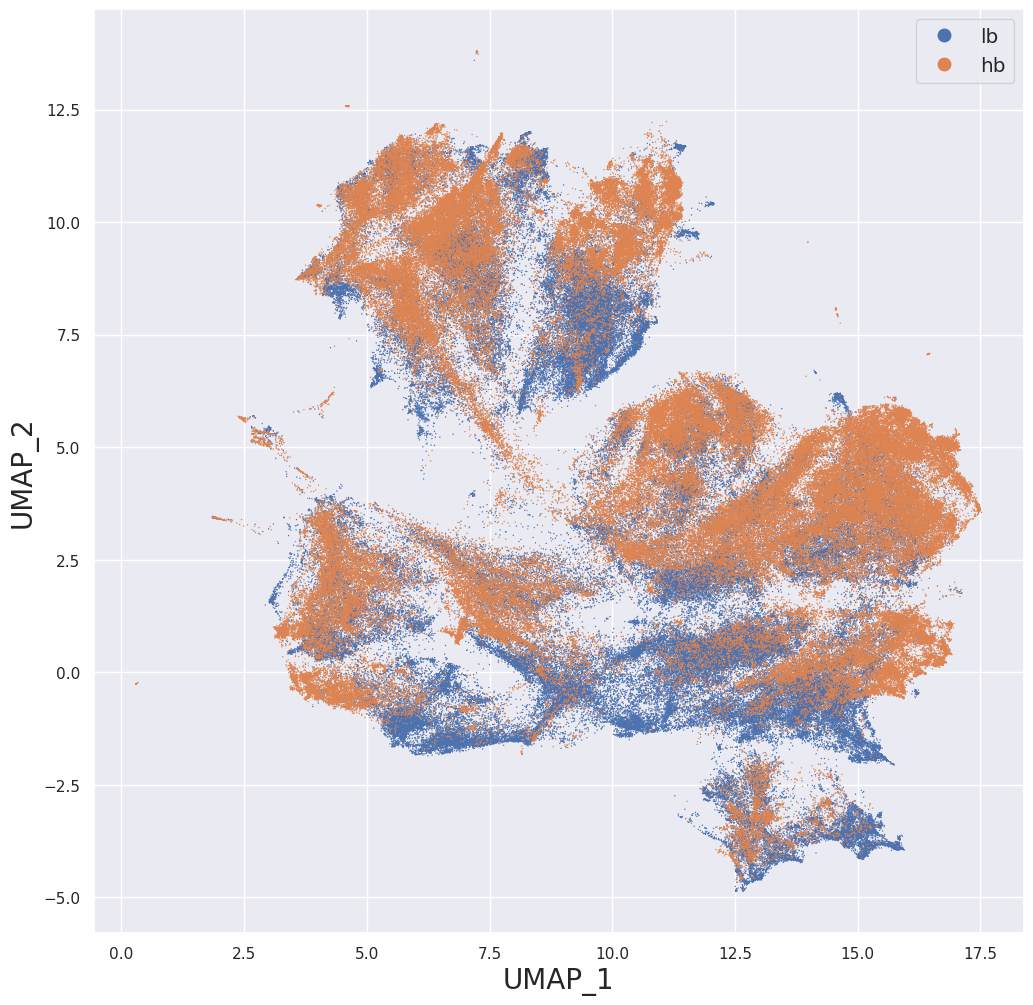

In [24]:
model_name = 'esm2'
red = 'UMAP'
dataset_name = 'trastuzumab_h_cdr3'

# Define hue_name
hue_name = 'affinity'

# Create the scatterplot
plt.figure(figsize=(12, 12))
scatter = sns.scatterplot(data=df, x='x', y='y', s=1, linewidth=0, hue=hue_name)

# Set the legend
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='large', markerscale=10)

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Save and show the plot
plt.savefig(f'{model_name}_{red}_{dataset_name}_{hue_name}.png')
plt.show()

In [32]:
df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)
cols_to_keep = ['Binds to', 'id']
df = df[cols_to_keep]
df

,Binds to,id
0,SARS-CoV2_WT;SARS-CoV2_Alpha;SARS-CoV2_Beta;SA...,1
1,SARS-CoV2_WT;SARS-CoV2_Alpha;SARS-CoV2_Delta;S...,2
2,SARS-CoV2_WT;SARS-CoV2_Alpha;SARS-CoV2_Beta;SA...,3
3,SARS-CoV2_WT;SARS-CoV2_Alpha;SARS-CoV2_Beta;SA...,4
4,SARS-CoV2_WT;SARS-CoV2_Alpha;SARS-CoV2_Beta;SA...,5
...,...,...
12530,SARS-CoV2_WT,12531
12531,SARS-CoV2_WT,12532
12532,SARS-CoV2_WT;SARS-CoV2_Omicron-BA1;SARS-CoV2_WT,12533
12533,SARS-CoV2_WT,12534
